# SigLIP Classification Evaluation

이 노트북은 SigLIP 분류 결과를 Ground Truth와 비교하여 성능을 평가합니다.

In [174]:
import os
import pandas as pd
import unicodedata
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    fbeta_score,
    accuracy_score,
    hamming_loss
)

## 유틸리티 함수

In [175]:
def sorted_dataframe(df1, df2, column):
    """preds dataframe을 gt에 맞게 정렬"""
    df1[column] = df1[column].apply(lambda x: unicodedata.normalize('NFC', str(x)))
    df2[column] = df2[column].apply(lambda x: unicodedata.normalize('NFC', str(x)))
    
    df2[column] = pd.Categorical(df2[column], categories=df1[column].tolist(), ordered=True)
    df2_sorted = df2.sort_values(column)
    
    return df2_sorted

In [176]:
def detailed_analysis(y_true, y_pred, average='default'):
    """상세한 정확도 분석 (Precision, Recall, F0.5)"""
    if average == 'default':
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f0_5 = fbeta_score(y_true, y_pred, beta=0.5, zero_division=0)
    else:
        precision = precision_score(y_true, y_pred, average=average, zero_division=0)
        recall = recall_score(y_true, y_pred, average=average, zero_division=0)
        f0_5 = fbeta_score(y_true, y_pred, beta=0.5, average=average, zero_division=0)
    
    return {
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f0.5": round(f0_5, 4)
    }

## Ground Truth 로드

In [177]:
# Ground Truth 파일 경로
gt_path = "../../../test_images/eval_data_gt.jsonl"
gt_df = pd.read_json(gt_path, lines=True, encoding='utf-8-sig')

# chair 객체 펼치기
gt_df = pd.concat([gt_df.drop('chair', axis=1), gt_df['chair'].apply(pd.Series)], axis=1)

# 레이블 이름 매핑: has_high_movable_chair -> has_high_chair
gt_df = gt_df.rename(columns={'has_high_movable_chair': 'has_high_chair'})

print(f"Ground Truth 데이터: {len(gt_df)}개 샘플")
print(f"\n컬럼: {list(gt_df.columns)}")

Ground Truth 데이터: 107개 샘플

컬럼: ['idx', 'file_path', 'has_step', 'width_class', 'has_movable_chair', 'has_high_chair', 'has_fixed_chair', 'has_floor_chair']


## Predictions 로드

In [178]:
# 평가할 predictions CSV 파일명
PREDICTIONS_FILE = 'siglip2_mldecoder_ft_0.75.csv'  # 파일명 수정 필요

preds_df = pd.read_csv(PREDICTIONS_FILE)

print(f"Predictions 데이터: {len(preds_df)}개 샘플")
print(f"\n컬럼: {list(preds_df.columns)}")

Predictions 데이터: 107개 샘플

컬럼: ['file_path', 'has_step', 'has_step_prob', 'has_movable_chair', 'has_movable_chair_prob', 'has_high_chair', 'has_high_chair_prob', 'has_fixed_chair', 'has_fixed_chair_prob', 'has_floor_chair', 'has_floor_chair_prob']


## 데이터 정렬

In [179]:
# GT에 맞게 predictions 정렬
preds_df_sorted = sorted_dataframe(gt_df, preds_df, 'file_path')

# 샘플 수 확인
assert len(gt_df) == len(preds_df_sorted), "GT와 Predictions의 샘플 수가 다릅니다!"
print(f"정렬 완료: {len(gt_df)}개 샘플")

정렬 완료: 107개 샘플


## 레이블별 평가

### 1. has_step

In [180]:
step_metrics = detailed_analysis(gt_df['has_step'], preds_df_sorted['has_step'])
print("has_step 평가 결과:")
print(step_metrics)

has_step 평가 결과:
{'precision': 0.0, 'recall': 0.0, 'f0.5': 0.0}


### 2. has_movable_chair

In [181]:
movable_metrics = detailed_analysis(gt_df['has_movable_chair'], preds_df_sorted['has_movable_chair'])
print("has_movable_chair 평가 결과:")
print(movable_metrics)

has_movable_chair 평가 결과:
{'precision': 0.9722, 'recall': 0.7527, 'f0.5': 0.9186}


### 3. has_high_chair

In [182]:
high_metrics = detailed_analysis(gt_df['has_high_chair'], preds_df_sorted['has_high_chair'])
print("has_high_chair 평가 결과:")
print(high_metrics)

has_high_chair 평가 결과:
{'precision': 0.7143, 'recall': 0.2632, 'f0.5': 0.5319}


### 4. has_fixed_chair

In [183]:
fixed_metrics = detailed_analysis(gt_df['has_fixed_chair'], preds_df_sorted['has_fixed_chair'])
print("has_fixed_chair 평가 결과:")
print(fixed_metrics)

has_fixed_chair 평가 결과:
{'precision': 0.7727, 'recall': 0.5484, 'f0.5': 0.7143}


### 5. has_floor_chair

In [184]:
floor_metrics = detailed_analysis(gt_df['has_floor_chair'], preds_df_sorted['has_floor_chair'])
print("has_floor_chair 평가 결과:")
print(floor_metrics)

has_floor_chair 평가 결과:
{'precision': 1.0, 'recall': 0.3333, 'f0.5': 0.7143}


## 전체 요약

In [185]:
# 전체 메트릭 요약
labels = ['has_step', 'has_movable_chair', 'has_high_chair', 'has_fixed_chair', 'has_floor_chair']
metrics_list = [step_metrics, movable_metrics, high_metrics, fixed_metrics, floor_metrics]

summary_df = pd.DataFrame(metrics_list, index=labels)
print("\n=== 전체 평가 결과 요약 ===")
print(summary_df)

# 평균 계산
print("\n=== 평균 ===")
print(summary_df.mean())


=== 전체 평가 결과 요약 ===
                   precision  recall    f0.5
has_step              0.0000  0.0000  0.0000
has_movable_chair     0.9722  0.7527  0.9186
has_high_chair        0.7143  0.2632  0.5319
has_fixed_chair       0.7727  0.5484  0.7143
has_floor_chair       1.0000  0.3333  0.7143

=== 평균 ===
precision    0.69184
recall       0.37952
f0.5         0.57582
dtype: float64


## Multi-Label 메트릭

In [186]:
# Multi-label 메트릭 계산
y_true = gt_df[labels].values
y_pred = preds_df_sorted[labels].values

# Subset Accuracy (모든 레이블이 정확히 일치)
subset_acc = accuracy_score(y_true, y_pred)

# Hamming Loss (레이블별 평균 오류율)
hamming = hamming_loss(y_true, y_pred)

# Micro/Macro Precision, Recall, F0.5
micro_metrics = detailed_analysis(y_true.flatten(), y_pred.flatten(), average='micro')
macro_metrics = detailed_analysis(y_true, y_pred, average='macro')

print("\n=== Multi-Label 메트릭 ===")
print(f"Subset Accuracy: {subset_acc:.4f}")
print(f"Hamming Loss: {hamming:.4f}")
print(f"Hamming Accuracy: {1 - hamming:.4f}")
print(f"\nMicro-average: {micro_metrics}")
print(f"Macro-average: {macro_metrics}")


=== Multi-Label 메트릭 ===
Subset Accuracy: 0.4112
Hamming Loss: 0.1607
Hamming Accuracy: 0.8393

Micro-average: {'precision': 0.8393, 'recall': 0.8393, 'f0.5': 0.8393}
Macro-average: {'precision': 0.6918, 'recall': 0.3795, 'f0.5': 0.5758}


## 혼동 행렬 (선택 사항)

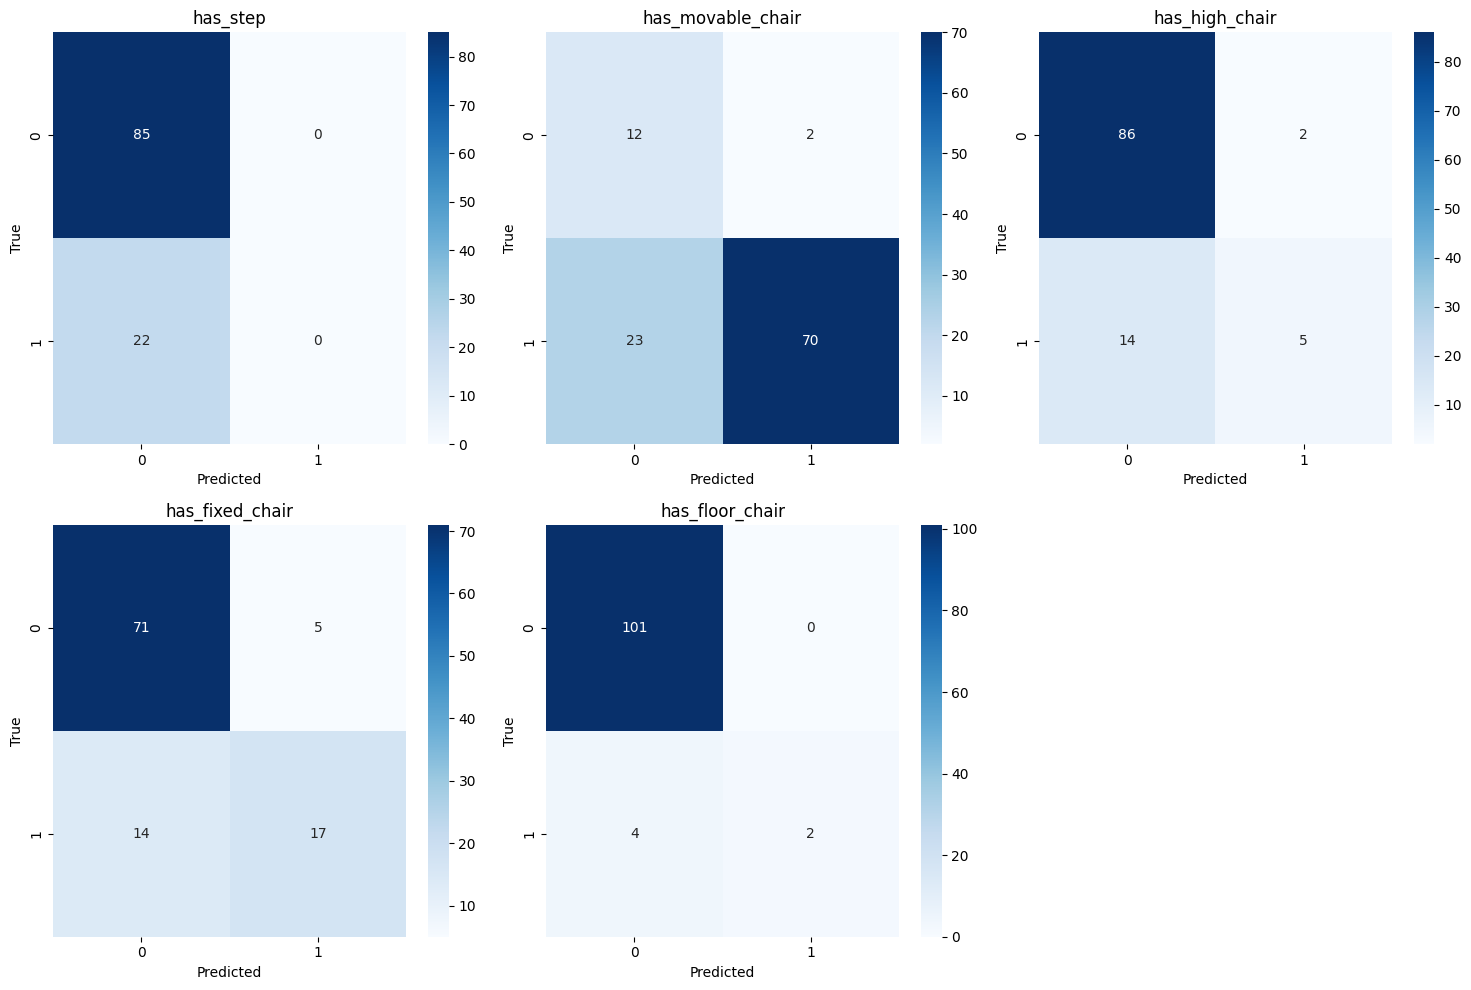

In [187]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 각 레이블별 혼동 행렬
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, label in enumerate(labels):
    cm = confusion_matrix(gt_df[label], preds_df_sorted[label])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{label}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

# 마지막 subplot 제거
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()